# 난지 한강공원 시간별 주차 예측 전체 프로세스

이 노트북은 이전 통합 분석 노트북의 핵심 흐름을 난지 한강공원 주차장 단일 사이트에 맞게 옮긴 분석 기록입니다.

- 포함: 데이터 확인, 운영시간 검증, 데이터 품질 점검, 패턴 기반 가중치 생성, Ridge 학습, 성능 평가, 해석
- 제외: station 선정, station 간 랭킹 비교
- 핵심 방식: `day_type x hour` 기본 패턴 + `month/year/hour` weight + Ridge
- 타깃: `estimated_active_cars` (일별 주차대수와 이용시간 기반의 시간별 추정 활성 차량 수)



In [1]:
%matplotlib inline
import koreanize_matplotlib
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
from __future__ import annotations

import math
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from IPython import get_ipython
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=UserWarning)
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().resolve()
if ROOT.name == 'Note' and ROOT.parent.name == 'hmw':
    ROOT = ROOT.parents[1]

DATASET_PATH = ROOT / 'ksm/nanji_hourly_modeling/nanji_hourly_model_dataset_2020_2026.csv'
RAW_DAILY_PATH = ROOT / 'hmw/Data/한강공원 주차장 일별 이용 현황.csv'
METHODOLOGY_PATH = ROOT / 'ksm/nanji_hourly_modeling/nanji_hourly_dataset_methodology.md'
FEATURE_DICT_PATH = ROOT / 'ksm/nanji_hourly_modeling/nanji_hourly_feature_dictionary.md'
WEATHER_DATA_DIR = ROOT / 'ose/Data'
OUTPUT_DIR = ROOT / 'hmw/Note/nanji_outputs'
REPORT_PATH = ROOT / 'hmw/Note/nanji_weighted_ridge_modeling_report.md'
OPERATING_HOURS = list(range(6, 24))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'estimated_active_cars'
ALPHA_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
DAY_TYPE_ORDER = ['weekday', 'offday']
WEATHER_FEATURE_COLUMNS = [
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature',
    'precipitation', 'rain', 'snowfall', 'snow_depth', 'weather_code', 'pressure_msl',
    'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation',
    'direct_radiation', 'diffuse_radiation', 'sunshine_duration',
]

print('ROOT:', ROOT)
print('DATASET_PATH:', DATASET_PATH)
print('RAW_DAILY_PATH:', RAW_DAILY_PATH)
print('REPORT_PATH:', REPORT_PATH)
print('WEATHER_DATA_DIR:', WEATHER_DATA_DIR)



ROOT: /Users/electrozone/Documents/nanji_work
DATASET_PATH: /Users/electrozone/Documents/nanji_work/ksm/nanji_hourly_modeling/nanji_hourly_model_dataset_2020_2026.csv
RAW_DAILY_PATH: /Users/electrozone/Documents/nanji_work/hmw/Data/한강공원 주차장 일별 이용 현황.csv
REPORT_PATH: /Users/electrozone/Documents/nanji_work/hmw/Note/nanji_weighted_ridge_modeling_report.md
WEATHER_DATA_DIR: /Users/electrozone/Documents/nanji_work/ose/Data


## 1. 데이터 소스와 분석 목적

이번 분석에서 먼저 확인해야 할 점은 다음 두 가지입니다.

1. 난지 주차장의 직접적인 시간별 실측 주차 로그가 있는가?
2. 현재 사용 중인 시간별 통합 CSV를 기준으로, 이번 분석에서 사용할 `2022~2025` 범위가 어떤 방식으로 만들어졌는가?

이후에 참고 통합 분석의 가중치 기반 모델링 방식을 적용해 머신러닝 분석을 수행합니다.



In [3]:
df = pd.read_csv(DATASET_PATH, parse_dates=['datetime', 'date'])
df = df[df['year'].between(2022, 2025)].copy()

weather_frames = []
for year in range(2022, 2026):
    weather_path = WEATHER_DATA_DIR / f'open_meteo_nanji_{year}.csv'
    weather_df = pd.read_csv(weather_path, parse_dates=['datetime', 'date'])
    weather_frames.append(weather_df)
weather_df = (
    pd.concat(weather_frames, ignore_index=True)
    .sort_values('datetime')
    .drop_duplicates('datetime')
    .reset_index(drop=True)
)
weather_keep_cols = ['datetime', 'weather_code_label', *WEATHER_FEATURE_COLUMNS]
df = df.merge(weather_df[weather_keep_cols], on='datetime', how='left')
df['weather_feature_available'] = df['temperature_2m'].notna().astype(int)

raw_daily = pd.read_csv(RAW_DAILY_PATH, encoding='cp949')
raw_daily = raw_daily[raw_daily['주차장명'].astype(str).str.contains('난지', na=False)].copy()
raw_daily['날짜'] = pd.to_datetime(raw_daily['날짜'])
raw_daily = raw_daily[raw_daily['날짜'].dt.year.between(2022, 2025)].copy()
raw_daily_summary = (
    raw_daily.groupby('날짜', as_index=False)
    .agg(
        daily_parking_count=('주차대수', 'sum'),
        daily_usage_minutes=('이용시간', 'sum'),
    )
    .sort_values('날짜')
    .reset_index(drop=True)
)

df['day_type'] = np.where(df['is_holiday_or_weekend'].eq(1), 'offday', 'weekday')
df['split'] = np.select(
    [
        df['year'].between(2022, 2023),
        df['year'].eq(2024),
        df['year'].eq(2025),
    ],
    ['train', 'valid', 'test'],
    default='other',
)

summary_df = pd.DataFrame([
    {
        'dataset': '시간별 통합 데이터셋',
        'rows': len(df),
        'date_min': df['datetime'].min(),
        'date_max': df['datetime'].max(),
        'note': '시간별 추정 타깃 + 외생 변수 + 날씨 결합본',
    },
    {
        'dataset': '난지 일별 주차 원본',
        'rows': len(raw_daily_summary),
        'date_min': raw_daily_summary['날짜'].min(),
        'date_max': raw_daily_summary['날짜'].max(),
        'note': '주차장명 == 난지1,2,3,4주차장 필터 후 일별 합산',
    },
    {
        'dataset': '난지 시간별 날씨 데이터',
        'rows': len(weather_df),
        'date_min': weather_df['datetime'].min(),
        'date_max': weather_df['datetime'].max(),
        'note': 'Open-Meteo 기반 시간별 기상 데이터',
    },
])

display(summary_df)
display(df.head())



,dataset,rows,date_min,date_max,note
0,시간별 통합 데이터셋,34920,2022-01-01,2025-12-31 23:00:00,시간별 추정 타깃 + 외생 변수 + 날씨 결합본
1,난지 일별 주차 원본,1455,2022-01-01,2025-12-31 00:00:00,"주차장명 == 난지1,2,3,4주차장 필터 후 일별 합산"
2,난지 시간별 날씨 데이터,35064,2022-01-01,2025-12-31 23:00:00,Open-Meteo 기반 시간별 기상 데이터


,datetime,date,hour,year,month,day,day_of_week,is_weekend,season,daily_parking_count,...,wind_speed_10m,wind_direction_10m,wind_gusts_10m,shortwave_radiation,direct_radiation,diffuse_radiation,sunshine_duration,weather_feature_available,day_type,split
0,2022-01-01 00:00:00,2022-01-01,0,2022,1,1,Saturday,True,winter,1167,...,5.5,337,12.2,0.0,0.0,0.0,0.0,1,offday,train
1,2022-01-01 01:00:00,2022-01-01,1,2022,1,1,Saturday,True,winter,1167,...,5.3,332,8.3,0.0,0.0,0.0,0.0,1,offday,train
2,2022-01-01 02:00:00,2022-01-01,2,2022,1,1,Saturday,True,winter,1167,...,2.2,180,6.8,0.0,0.0,0.0,0.0,1,offday,train
3,2022-01-01 03:00:00,2022-01-01,3,2022,1,1,Saturday,True,winter,1167,...,1.4,180,3.2,0.0,0.0,0.0,0.0,1,offday,train
4,2022-01-01 04:00:00,2022-01-01,4,2022,1,1,Saturday,True,winter,1167,...,2.5,188,4.0,0.0,0.0,0.0,0.0,1,offday,train


## 2. 현재 시간별 데이터가 운영시간 조건에 맞는지 확인

검증 조건:

- 하루 이용량을 단순히 `24`로 나눈 데이터가 아니어야 함
- 난지 주차장의 운영시간은 `06:00~23:00`으로 가정
- 따라서 `0~5시`는 운영시간 외로 보고 수요를 `0`으로 간주하며, `6~23시`가 실제 운영시간 패턴을 가져야 함



In [4]:
hour_summary = (
    df.groupby('hour', as_index=False)
    .agg(
        rows=('hour', 'size'),
        nonzero_entries=('estimated_entries', lambda s: int((s > 0).sum())),
        nonzero_active=('estimated_active_cars', lambda s: int((s > 0).sum())),
        max_hourly_share=('hourly_share', 'max'),
        max_entries=('estimated_entries', 'max'),
        max_active=('estimated_active_cars', 'max'),
    )
)

hour_zero_check = pd.DataFrame([
    {
        'rows_0_5': int(df['hour'].between(0, 5).sum()),
        'nonzero_entries_0_5': int((df.loc[df['hour'].between(0, 5), 'estimated_entries'] > 0).sum()),
        'nonzero_active_0_5': int((df.loc[df['hour'].between(0, 5), 'estimated_active_cars'] > 0).sum()),
        'rows_23': int((df['hour'] == 23).sum()),
        'nonzero_entries_23': int((df.loc[df['hour'] == 23, 'estimated_entries'] > 0).sum()),
    }
])

display(hour_summary)
display(hour_zero_check)

sample_day = df['date'].min()
sample_profile = df[df['date'] == sample_day][['datetime', 'hour', 'hourly_share', 'estimated_entries', 'estimated_active_cars']].copy()
display(sample_profile)

print('hourly_share 합계 (sample day):', sample_profile['hourly_share'].sum())
print('estimated_entries == daily_parking_count * hourly_share max abs diff:', (df['estimated_entries'] - df['daily_parking_count'] * df['hourly_share']).abs().max())


,hour,rows,nonzero_entries,nonzero_active,max_hourly_share,max_entries,max_active
0,0,1455,0,0,0.000000,0.000000,0.000000
1,1,1455,0,0,0.000000,0.000000,0.000000
2,2,1455,0,0,0.000000,0.000000,0.000000
3,3,1455,0,0,0.000000,0.000000,0.000000
4,4,1455,0,0,0.000000,0.000000,0.000000
5,5,1455,0,0,0.000000,0.000000,0.000000
6,6,1455,1455,1455,0.007784,23.951913,23.951913
7,7,1455,1455,1455,0.016818,50.135378,71.131206
8,8,1455,1455,1455,0.031732,95.213171,138.447664
9,9,1455,1455,1455,0.052656,164.681459,241.543661


,rows_0_5,nonzero_entries_0_5,nonzero_active_0_5,rows_23,nonzero_entries_23
0,8730,0,0,1455,1455


,datetime,hour,hourly_share,estimated_entries,estimated_active_cars
0,2022-01-01 00:00:00,0,0.000000,0.000000,0.000000
1,2022-01-01 01:00:00,1,0.000000,0.000000,0.000000
2,2022-01-01 02:00:00,2,0.000000,0.000000,0.000000
3,2022-01-01 03:00:00,3,0.000000,0.000000,0.000000
4,2022-01-01 04:00:00,4,0.000000,0.000000,0.000000
5,2022-01-01 05:00:00,5,0.000000,0.000000,0.000000
6,2022-01-01 06:00:00,6,0.004060,4.738084,3.594705
7,2022-01-01 07:00:00,7,0.009140,10.666347,8.092378
8,2022-01-01 08:00:00,8,0.018253,21.301285,16.160928
9,2022-01-01 09:00:00,9,0.032483,37.907956,28.760130


hourly_share 합계 (sample day): 0.9999999999999992
estimated_entries == daily_parking_count * hourly_share max abs diff: 6.821210263296962e-13


## 3. 시간별 데이터 생성 방식 정리

현재 시간별 CSV는 **실측 시간별 주차 로그**가 아니라, 일별 원본을 시간축으로 확장한 추정 데이터입니다.

핵심 흐름은 아래와 같습니다.

1. `hmw/Data/한강공원 주차장 일별 이용 현황.csv`에서 난지 주차장 행 선택
2. 날짜별 `주차대수`, `이용시간` 합산
3. 평일/주말 + 계절별 시간 프로필로 `hourly_share`, `estimated_entries` 생성
4. 평균 체류시간 기반으로 `estimated_active_cars` 생성
5. 공휴일, 교통, 자전거, 문화행사, 정적 참고 변수를 병합



In [5]:
methodology_text = METHODOLOGY_PATH.read_text(encoding='utf-8')
feature_dict_text = FEATURE_DICT_PATH.read_text(encoding='utf-8')

display(Markdown('### 방법론 문서 발췌'))
display(Markdown('\n'.join(methodology_text.splitlines()[:18])))

display(Markdown('### Feature Dictionary 발췌'))
feature_lines = feature_dict_text.splitlines()
excerpt = []
capture = False
for line in feature_lines:
    if line.startswith('### `hourly_share`'):
        capture = True
    if capture:
        excerpt.append(line)
    if capture and line.startswith('### `estimated_active_cars_change`'):
        break
display(Markdown('\n'.join(excerpt)))


### 방법론 문서 발췌

# 난지 시간별 데이터셋 생성 방법

## 목적

- 난지 한강공원 주차 예측을 위한 `시간별 학습 데이터셋`을 만든다.
- 실제 시간별 주차 로그가 없기 때문에, 일별 주차 원본을 시간축으로 확장한 뒤 난지 선택 데이터를 feature로 결합한다.

## 생성 흐름

1. `hmw/Data/한강공원 주차장 일별 이용 현황.csv`에서 난지 주차장 행만 선택
2. 날짜별 `주차대수`, `이용시간` 합산
3. 평일/주말 + 계절별 시간 프로필로 `estimated_entries` 생성
4. 평균 체류시간 기반으로 `estimated_active_cars` 생성
5. 공휴일 달력 병합
6. 버스/지하철 월별 시간대 패턴 병합
7. 자전거 대여이력의 일별-시간대 집계 병합
8. 문화행사 일별 집계 병합
9. 정적 참고 데이터(주변 공영주차장, 킥보드 주차구역) 요약치 추가

### Feature Dictionary 발췌

### `hourly_share`
- 의미: 하루 총 주차수요를 해당 시간에 배분하는 비율
- 범위: `0 ~ 1`
- 설명: 평일/주말과 계절별 프로필을 이용해 만든 시간 분배 비율

### `estimated_entries`
- 의미: 해당 시간에 주차장으로 들어온 차량 수의 추정값
- 설명: 실제 입차 로그가 아니라 규칙 기반 추정값

### `estimated_active_cars`
- 의미: 해당 시간에 주차장에 머물러 있는 차량 수의 추정값
- 설명: `estimated_entries`와 평균 체류시간을 이용해 계산한 활성 차량 수

### `estimated_active_cars_change`

## 4. train / valid / test 구간 정의

이번 분석의 `train`, `valid`, `test`는 서로 다른 파일이 아니라, **같은 난지 시간별 통합 데이터셋을 연도 구간으로 나눈 데이터**입니다.

- `train`: `2022-01-01 ~ 2023-12-31`에 해당하는 시간별 행
- `valid`: `2024-01-01 ~ 2024-12-31`에 해당하는 시간별 행
- `test`: `2025-01-01 ~ 2025-12-31`에 해당하는 시간별 행

각 행에는 `datetime`, `date`, `year`, `month`, `hour`, `is_holiday`, `is_long_weekend`, `day_type`, `estimated_entries`, `estimated_active_cars`와 각종 외생 변수(버스/지하철/자전거/행사 관련 컬럼)가 들어 있습니다. 이후 모델링 단계에서 여기에 `base_value`, `month_weight`, `hour_weight`, `pattern_prior`, `corrected_pattern_prior` 같은 파생 feature가 추가됩니다.

용도는 아래처럼 구분합니다.

- `train`: 기본 패턴식(`base_value`) 학습, `month_weight`/`hour_weight` 계산, Ridge 회귀 학습
- `valid`: alpha 선택과 모델 구조 비교
- `test`: 최종 일반화 성능 평가



In [6]:
split_summary = (
    df.groupby('split', as_index=False)
    .agg(
        row_count=('datetime', 'size'),
        start_datetime=('datetime', 'min'),
        end_datetime=('datetime', 'max'),
        unique_days=('date', 'nunique'),
    )
)
display(split_summary)



,split,row_count,start_datetime,end_datetime,unique_days
0,test,8760,2025-01-01,2025-12-31 23:00:00,365
1,train,17400,2022-01-01,2023-12-31 23:00:00,725
2,valid,8760,2024-01-01,2024-12-31 23:00:00,365


## 4. 분석 함수 정의

이번 노트북은 `year_weight`를 사용하지 않고, `month_weight + hour_weight` 중심 구조만 사용합니다.

- `day_type x hour` 기본 패턴식 생성
- `month_weight`로 월별 규모 보정
- `hour_weight`로 운영시간(6~23시) 시간대 보정
- 최종 Ridge는 이 패턴 feature와 외생 변수를 사용해 학습
- 외생 변수에는 기존 교통/행사 변수에 더해 시간별 날씨 feature도 포함됨



In [7]:
def non_negative_only(values: np.ndarray) -> np.ndarray:
    return np.clip(values, 0, None)


def enforce_operating_hours(frame: pd.DataFrame, preds: np.ndarray) -> np.ndarray:
    adjusted = np.asarray(preds, dtype=float).copy()
    adjusted[~frame['hour'].isin(OPERATING_HOURS).to_numpy()] = 0.0
    return adjusted


def calc_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


def fit_day_type_hour_models(train_df: pd.DataFrame, target: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    formula_rows = []
    base_rows = []
    for day_type in DAY_TYPE_ORDER:
        sub = (
            train_df[train_df['day_type'] == day_type]
            .groupby('hour', as_index=False)[target]
            .mean()
            .sort_values('hour')
        )
        angle = 2 * np.pi * sub['hour'].to_numpy(dtype=float) / 24.0
        X = np.column_stack([np.ones(len(sub)), np.sin(angle), np.cos(angle)])
        y = sub[target].to_numpy(dtype=float)
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        sub['base_value'] = np.clip(X @ beta, 0, None)
        sub['day_type'] = day_type
        base_rows.append(sub[['day_type', 'hour', 'base_value']])
        formula_rows.append({
            'target': target,
            'day_type': day_type,
            'intercept': float(beta[0]),
            'sin_hour_coef': float(beta[1]),
            'cos_hour_coef': float(beta[2]),
            'formula': f'{beta[0]:.6f} + ({beta[1]:+.6f} * sin(2pi*hour/24)) + ({beta[2]:+.6f} * cos(2pi*hour/24))',
        })
    return pd.DataFrame(formula_rows), pd.concat(base_rows, ignore_index=True)


def build_weight_maps(all_df: pd.DataFrame, base_df: pd.DataFrame, target: str):
    all_base = all_df.merge(base_df, on=['day_type', 'hour'], how='left')
    all_base['month_ratio'] = np.where(all_base['base_value'] > 0, all_base[target] / all_base['base_value'], 1.0)
    month_weight_map = all_base.groupby('month')['month_ratio'].mean().to_dict()
    month_mean = float(np.mean(list(month_weight_map.values())))
    month_weight_map = {int(k): float(v / month_mean) for k, v in month_weight_map.items()}

    all_base['month_weight'] = all_base['month'].map(month_weight_map).fillna(1.0)
    all_base['pattern_prior'] = all_base['base_value'] * all_base['month_weight']
    hour_base = all_base[all_base['hour'].isin(OPERATING_HOURS)].copy()
    hour_base['hour_ratio'] = np.where(hour_base['pattern_prior'] > 0, hour_base[target] / hour_base['pattern_prior'], 1.0)
    hour_weight_map = hour_base.groupby('hour')['hour_ratio'].mean().to_dict()
    hour_mean = float(np.mean(list(hour_weight_map.values())))
    hour_weight_map = {int(k): float(v / hour_mean) for k, v in hour_weight_map.items()}
    return month_weight_map, hour_weight_map, all_base


def attach_pattern_features(in_df: pd.DataFrame, base_df: pd.DataFrame, month_weight_map, hour_weight_map) -> pd.DataFrame:
    out = in_df.merge(base_df, on=['day_type', 'hour'], how='left')
    out['month_weight'] = out['month'].map(month_weight_map).fillna(1.0)
    out['pattern_prior'] = out['base_value'] * out['month_weight']
    out['hour_weight'] = out['hour'].map(hour_weight_map).fillna(1.0)
    out['corrected_pattern_prior'] = out['pattern_prior'] * out['hour_weight']
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24.0)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24.0)
    out['month_sin'] = np.sin(2 * np.pi * out['month'] / 12.0)
    out['month_cos'] = np.cos(2 * np.pi * out['month'] / 12.0)
    out['day_type_offday'] = out['day_type'].eq('offday').astype(int)
    return out.fillna(0)


def feature_sets() -> dict[str, list[str]]:
    core = [
        'base_value', 'month_weight', 'hour_weight',
        'pattern_prior', 'corrected_pattern_prior', 'day_type_offday',
    ]
    extended = core + [
        'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
        'is_holiday', 'is_long_weekend',
        'bus_boardings', 'bus_alightings', 'subway_boardings', 'subway_alightings',
        'bike_rentals', 'bike_returns', 'bike_rental_minutes_sum', 'bike_rental_distance_m_sum',
        'event_count', 'free_event_count', 'paid_event_count', 'evening_event_count',
        'bus_feature_available', 'subway_feature_available', 'bike_feature_available', 'culture_feature_available',
        *WEATHER_FEATURE_COLUMNS, 'weather_feature_available',
    ]
    return {'weighted_core': core, 'weighted_extended': extended}


def prune_correlated_features(train_df: pd.DataFrame, feature_map: dict[str, list[str]], threshold: float = 0.9):
    pruned_map = {}
    pruning_rows = []

    for model_name, columns in feature_map.items():
        corr = train_df[columns].corr().abs()
        target_corr = train_df[columns].corrwith(train_df[TARGET]).abs()
        kept = []
        dropped = set()

        for col in columns:
            if col in dropped:
                continue
            candidate = col
            for other in columns:
                if other == candidate or other in dropped or other in kept:
                    continue
                corr_value = corr.loc[candidate, other]
                if pd.notna(corr_value) and corr_value >= threshold:
                    if float(target_corr.get(other, 0.0)) > float(target_corr.get(candidate, 0.0)):
                        dropped.add(candidate)
                        pruning_rows.append({
                            'model_name': model_name,
                            'kept_feature': other,
                            'dropped_feature': candidate,
                            'abs_corr': float(corr_value),
                            'threshold': threshold,
                        })
                        candidate = other
                    else:
                        dropped.add(other)
                        pruning_rows.append({
                            'model_name': model_name,
                            'kept_feature': candidate,
                            'dropped_feature': other,
                            'abs_corr': float(corr_value),
                            'threshold': threshold,
                        })
            if candidate not in dropped and candidate not in kept:
                kept.append(candidate)

        pruned_map[model_name] = kept

    return pruned_map, pd.DataFrame(pruning_rows)


def prepare_split_frames(df: pd.DataFrame, base_df: pd.DataFrame, month_weight_map, hour_weight_map):
    processed = {}
    for split_name in ['train', 'valid', 'test']:
        part = df[df['split'] == split_name].copy()
        processed[split_name] = attach_pattern_features(part, base_df, month_weight_map, hour_weight_map)
    return processed


def train_models(processed_splits: dict[str, pd.DataFrame], feature_map: dict[str, list[str]]):
    tuning_rows = []
    metric_rows = []
    importance_rows = []

    for model_name, columns in feature_map.items():
        best_alpha = None
        best_model = None
        best_valid_rmse = math.inf

        X_train = processed_splits['train'][columns]
        y_train = processed_splits['train'][TARGET]
        X_valid = processed_splits['valid'][columns]
        y_valid = processed_splits['valid'][TARGET]

        for alpha in ALPHA_GRID:
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('ridge', Ridge(alpha=alpha)),
            ])
            model.fit(X_train, y_train)
            valid_pred = non_negative_only(model.predict(X_valid))
            valid_pred = enforce_operating_hours(processed_splits['valid'], valid_pred)
            metrics = calc_metrics(y_valid, valid_pred)
            tuning_rows.append({'model_name': model_name, 'alpha': alpha, **metrics})
            if metrics['rmse'] < best_valid_rmse:
                best_valid_rmse = metrics['rmse']
                best_alpha = alpha
                best_model = model

        scaler = best_model.named_steps['scaler']
        ridge = best_model.named_steps['ridge']
        scaled_coefs = ridge.coef_ / scaler.scale_
        coef_abs_sum = float(np.abs(scaled_coefs).sum())
        for feature, coef in zip(columns, scaled_coefs):
            importance_rows.append({
                'model_name': model_name,
                'feature': feature,
                'alpha': best_alpha,
                'coefficient': float(coef),
                'importance_abs': float(abs(coef)),
                'importance_ratio': float(abs(coef) / coef_abs_sum) if coef_abs_sum else 0.0,
            })

        for split_name in ['train', 'valid', 'test']:
            frame = processed_splits[split_name]
            pred = non_negative_only(best_model.predict(frame[columns]))
            pred = enforce_operating_hours(frame, pred)
            processed_splits[split_name][f'{model_name}_prediction'] = pred
            metric_rows.append({'model_name': model_name, 'alpha': best_alpha, 'split': split_name, **calc_metrics(frame[TARGET], pred)})

    return pd.DataFrame(tuning_rows), pd.DataFrame(metric_rows), pd.DataFrame(importance_rows)




## 5. 데이터 품질과 feature 가용성 점검

모델링 전에 다음을 확인합니다.

- 시간 중복 여부
- 타깃 결측 여부
- 외생 변수 가용률
- split 구간별 행 수



In [8]:
quality_df = pd.DataFrame([
    {
        'rows': len(df),
        'unique_datetime': df['datetime'].nunique(),
        'duplicate_rows': int(len(df) - df['datetime'].nunique()),
        'target_missing': int(df[TARGET].isna().sum()),
        'target_min': float(df[TARGET].min()),
        'target_max': float(df[TARGET].max()),
        'date_min': df['datetime'].min(),
        'date_max': df['datetime'].max(),
    }
])

coverage_df = (
    df[['bus_feature_available', 'subway_feature_available', 'bike_feature_available', 'culture_feature_available', 'weather_feature_available']]
    .mean()
    .rename('coverage_rate')
    .reset_index()
    .rename(columns={'index': 'feature'})
)

missing_df = (
    df.isna().sum()
    .sort_values(ascending=False)
    .rename('missing_count')
    .reset_index()
    .rename(columns={'index': 'feature'})
    .head(12)
)

split_summary = (
    df.groupby('split', as_index=False)
    .agg(
        rows=('datetime', 'size'),
        date_min=('datetime', 'min'),
        date_max=('datetime', 'max'),
        target_mean=(TARGET, 'mean'),
    )
)

display(quality_df)
display(coverage_df)
display(missing_df)
display(split_summary)



,rows,unique_datetime,duplicate_rows,target_missing,target_min,target_max,date_min,date_max
0,34920,34920,0,0,0.0,1219.573526,2022-01-01,2025-12-31 23:00:00


,feature,coverage_rate
0,bus_feature_available,0.719903
1,subway_feature_available,0.924456
2,bike_feature_available,0.331959
3,culture_feature_available,0.187629
4,weather_feature_available,1.000000


,feature,missing_count
0,holiday_name,33144
1,bus_boardings,9781
2,bus_alightings,9781
3,dew_point_2m,0
4,snowfall,0
5,rain,0
6,precipitation,0
7,apparent_temperature,0
8,relative_humidity_2m,0
9,weather_code,0


,split,rows,date_min,date_max,target_mean
0,test,8760,2025-01-01,2025-12-31 23:00:00,77.736453
1,train,17400,2022-01-01,2023-12-31 23:00:00,82.802460
2,valid,8760,2024-01-01,2024-12-31 23:00:00,78.513324


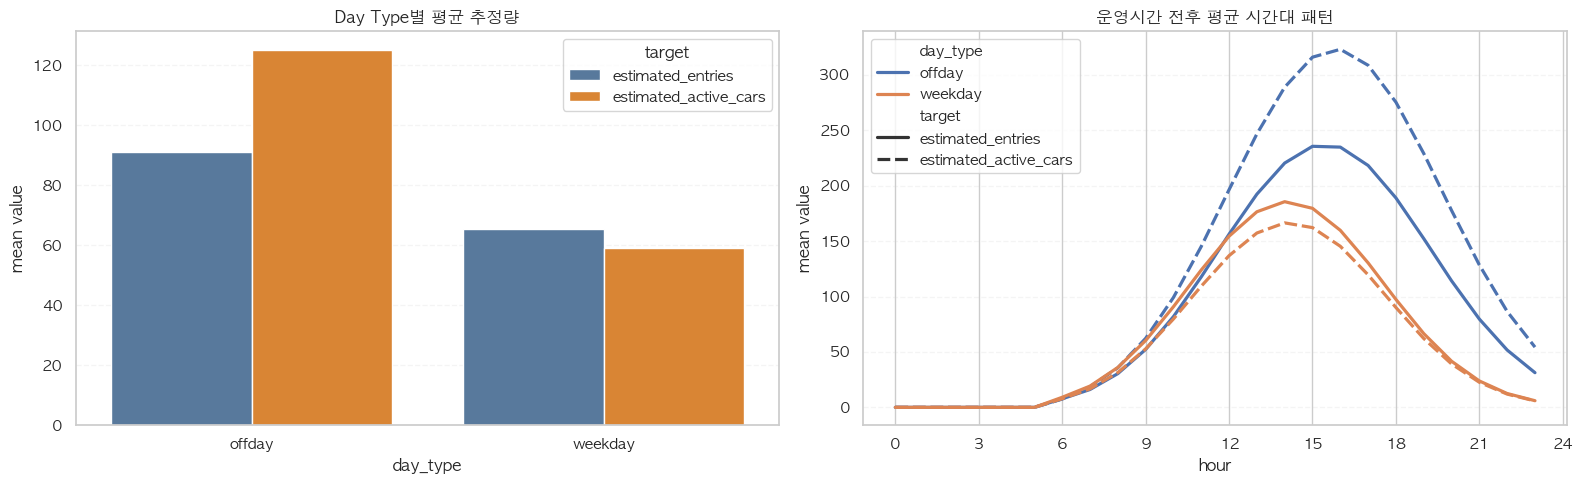

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

day_type_summary = (
    df.groupby('day_type', as_index=False)[['estimated_entries', 'estimated_active_cars']]
    .mean()
    .melt(id_vars='day_type', var_name='target', value_name='mean_value')
)
sns.barplot(data=day_type_summary, x='day_type', y='mean_value', hue='target', ax=axes[0], palette=['#4C78A8', '#F58518'])
axes[0].set_title('Day Type별 평균 추정량')
axes[0].set_xlabel('day_type')
axes[0].set_ylabel('mean value')
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

hourly_profile = (
    df.groupby(['day_type', 'hour'], as_index=False)[['estimated_entries', 'estimated_active_cars']]
    .mean()
    .melt(id_vars=['day_type', 'hour'], var_name='target', value_name='mean_value')
)
sns.lineplot(data=hourly_profile, x='hour', y='mean_value', hue='day_type', style='target', linewidth=2.3, ax=axes[1])
axes[1].set_title('운영시간 전후 평균 시간대 패턴')
axes[1].set_xlabel('hour')
axes[1].set_ylabel('mean value')
axes[1].grid(axis='y', alpha=0.2, linestyle='--')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


## 6. 참고 프로세스 기반 패턴 가중치 생성

이 단계가 이번 프로젝트의 핵심입니다.

1. `train(2022~2023)`에서 `weekday/offday x hour` 평균 패턴을 학습
2. 기본 패턴 대비 월별 비율로 `month_weight` 생성
3. `pattern_prior = base_value * month_weight` 구성
4. `6~23시` 운영시간 구간에서만 `pattern_prior` 대비 비율로 `hour_weight` 생성
5. `corrected_pattern_prior = pattern_prior * hour_weight`
6. 이 구조를 baseline 모델로 평가

`23시 hour_weight`가 `22시`보다 다시 약간 올라가는 것은 계산 오류라기보다 비율 구조의 결과입니다. `hour_weight`는 `actual / pattern_prior`에 가깝게 계산되므로, `22시 -> 23시`로 갈 때 실제 점유 추정값보다 기본 패턴(`pattern_prior`)이 더 빠르게 감소하면 `23시`의 비율이 다시 커질 수 있습니다. 즉, 마감 시간대에도 실제 점유가 완전히 0으로 꺼지지 않는데 기본 패턴식은 더 급하게 하락하기 때문에 나타나는 보정 효과로 해석하는 것이 맞습니다.



In [10]:
train_df = df[df['split'] == 'train'].copy()
formula_df, base_df = fit_day_type_hour_models(train_df, TARGET)
month_weight_map, hour_weight_map, all_base = build_weight_maps(train_df, base_df, TARGET)

all_base['month_weight_row'] = np.where(
    all_base['base_value'] > 0,
    all_base[TARGET] / all_base['base_value'],
    1.0,
)
all_base['month_weight_row'] = all_base['month_weight_row'] / np.mean(list(all_base.groupby('month')['month_weight_row'].mean().to_dict().values()))

hour_base = all_base[all_base['hour'].isin(OPERATING_HOURS)].copy()
hour_base['hour_weight_row'] = np.where(
    hour_base['pattern_prior'] > 0,
    hour_base[TARGET] / hour_base['pattern_prior'],
    1.0,
)
hour_base['hour_weight_row'] = hour_base['hour_weight_row'] / np.mean(list(hour_weight_map.values()))

month_weight_summary = (
    all_base.groupby('month', as_index=False)
    .agg(mean_weight=('month_weight_row', 'mean'))
    .sort_values('month')
)
hour_weight_summary = (
    hour_base.groupby('hour', as_index=False)
    .agg(mean_weight=('hour_weight_row', 'mean'))
    .sort_values('hour')
)

weight_df = pd.DataFrame([
    {'weight_type': 'month_weight', 'key': k, 'value': v} for k, v in month_weight_map.items()
] + [
    {'weight_type': 'hour_weight', 'key': k, 'value': v} for k, v in hour_weight_map.items()
])

display(formula_df)
display(weight_df[weight_df['weight_type'] == 'month_weight'].sort_values('key'))
display(month_weight_summary)
display(weight_df[weight_df['weight_type'] == 'hour_weight'].sort_values('value', ascending=False).head(12))
display(hour_weight_summary)
print('hour_weight 계산 대상 시간:', sorted(weight_df[weight_df['weight_type'] == 'hour_weight']['key'].unique().tolist()))



,target,day_type,intercept,sin_hour_coef,cos_hour_coef,formula
0,estimated_active_cars,weekday,61.437302,-46.329213,-70.418263,61.437302 + (-46.329213 * sin(2pi*hour/24)) + ...
1,estimated_active_cars,offday,128.203422,-138.708299,-91.815457,128.203422 + (-138.708299 * sin(2pi*hour/24)) ...


,weight_type,key,value
0,month_weight,1,0.581680
1,month_weight,2,0.650624
2,month_weight,3,0.887411
3,month_weight,4,1.182620
4,month_weight,5,1.313200
5,month_weight,6,1.268792
6,month_weight,7,1.071624
7,month_weight,8,1.097217
8,month_weight,9,1.276365
9,month_weight,10,1.110980


,month,mean_weight
0,1,0.581680
1,2,0.650624
2,3,0.887411
3,4,1.182620
4,5,1.313200
5,6,1.268792
6,7,1.071624
7,8,1.097217
8,9,1.276365
9,10,1.110980


,weight_type,key,value
20,hour_weight,14,1.345728
21,hour_weight,15,1.333959
19,hour_weight,13,1.306304
22,hour_weight,16,1.272022
18,hour_weight,12,1.221427
23,hour_weight,17,1.168424
17,hour_weight,11,1.102253
29,hour_weight,23,1.073611
24,hour_weight,18,1.038022
16,hour_weight,10,0.964627


,hour,mean_weight
0,6,0.696093
1,7,0.678751
2,8,0.618181
3,9,0.701640
4,10,0.815698
5,11,0.932075
6,12,1.032850
7,13,1.104623
8,14,1.137960
9,15,1.128008


hour_weight 계산 대상 시간: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


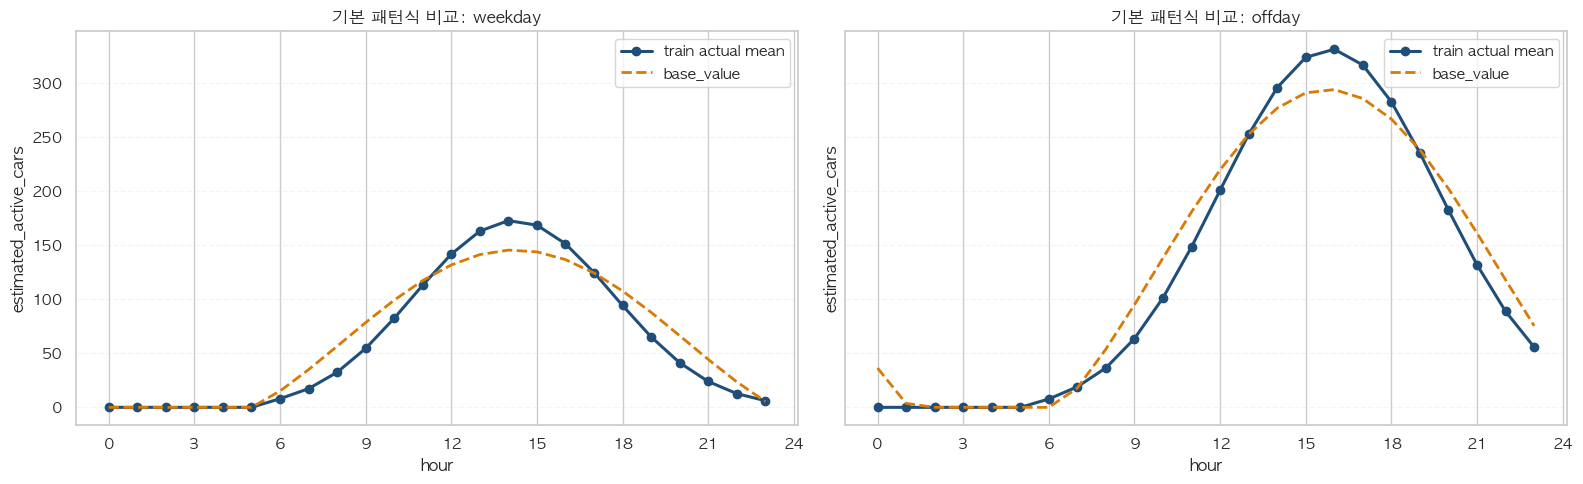

In [11]:
base_compare = (
    df[df['split'] == 'train'][['day_type', 'hour', TARGET]]
    .groupby(['day_type', 'hour'], as_index=False)
    .mean()
    .merge(base_df, on=['day_type', 'hour'], how='left')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, day_type in zip(axes, DAY_TYPE_ORDER):
    sub = base_compare[base_compare['day_type'] == day_type]
    ax.plot(sub['hour'], sub[TARGET], marker='o', linewidth=2.2, label='train actual mean', color='#1f4e79')
    ax.plot(sub['hour'], sub['base_value'], linestyle='--', linewidth=2.0, label='base_value', color='#d97a04')
    ax.set_title(f'기본 패턴식 비교: {day_type}')
    ax.set_xlabel('hour')
    ax.set_ylabel(TARGET)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.legend(frameon=True)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


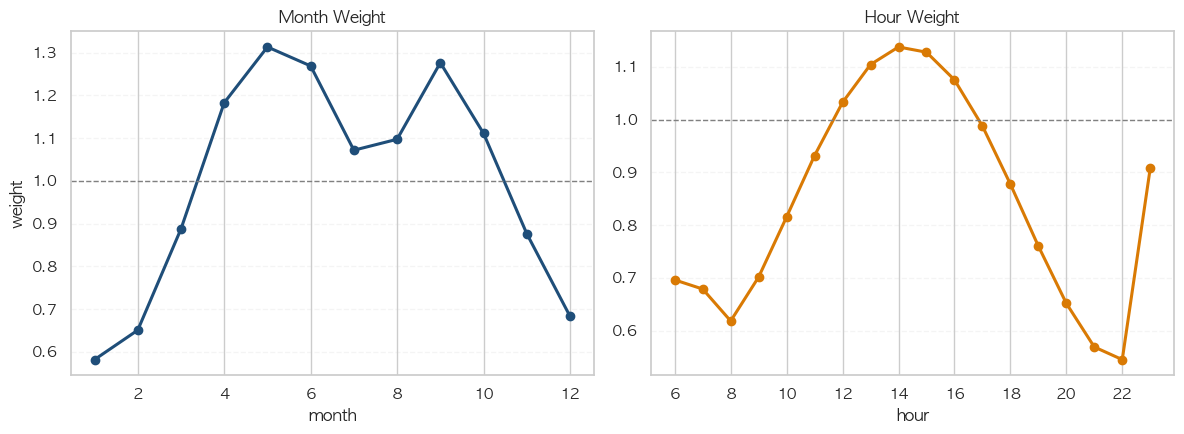

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

month_view = month_weight_summary.copy()
axes[0].plot(month_view['month'], month_view['mean_weight'], marker='o', linewidth=2.2, color='#1f4e79')
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Month Weight')
axes[0].set_xlabel('month')
axes[0].set_ylabel('weight')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

hour_view = hour_weight_summary.copy()
axes[1].plot(hour_view['hour'], hour_view['mean_weight'], marker='o', linewidth=2.2, color='#d97a04')
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Hour Weight')
axes[1].set_xlabel('hour')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

for ax in axes:
    ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()



## 7. 머신러닝 분석: Ridge 학습과 검증

이번 분석은 `year_weight` 없이 진행합니다.

모델 구성:

- `weighted_core`: `base_value`, `month_weight`, `hour_weight`, `pattern_prior`, `corrected_pattern_prior`, `day_type_offday`만 사용하는 패턴 중심 모델
- `weighted_extended`: `weighted_core`에 `hour/month sin-cos`, `is_holiday`, `is_long_weekend`, 버스/지하철/따릉이/행사/날씨 변수와 availability flag를 추가한 확장 모델

왜 `year_weight`를 빼는가:

- `train(2022~2023)`에서 계산한 연도별 차이가 매우 작았음
- 실제 train 기준 `year_weight`는 `2022 = 0.9949`, `2023 = 1.0051` 수준으로 거의 `1`에 가까웠음
- `2024`, `2025`는 train에서 직접 학습한 연도가 아니므로 순수 평가 구조에서는 안정적인 `year_weight`를 주기 어려움
- 이미 `month_weight`, `hour_weight`, 공휴일/연휴, 교통/행사/날씨 feature가 연도 수준 차이의 상당 부분을 설명하고 있음
- 따라서 `year_weight`를 추가해도 성능 개선이 거의 없었고, 이번 최종 구조에서는 제외하는 편이 더 자연스러웠음

실사용 관점의 해석:

- 오프라인 비교에서는 `weighted_extended`가 더 좋을 수 있음
- 하지만 미래 시점의 버스/지하철/자전거/행사/날씨 값은 예측 시점에 모두 안정적으로 알 수 없으므로, 실제 운용 모델은 `weighted_core`로 보는 것이 더 적절함
- 행사와 날씨 데이터는 예측용 입력값이 아니라, 과거 특정 시기의 수요 변동을 해석하는 참고 근거 정도로만 활용함
- `lag`, `rolling` 같은 시계열 패턴 변수는 이번 설계 원칙상 넣지 않음

검증 방식:

- `train`: 2022~2023
- `valid`: 2024
- `test`: 2025
- `month/hour weight`는 모두 `train`만 보고 계산




In [13]:
processed_splits = prepare_split_frames(df, base_df, month_weight_map, hour_weight_map)
feature_map, pruning_df = prune_correlated_features(processed_splits['train'], feature_sets(), threshold=0.9)
tuning_df, metrics_df, importance_df = train_models(processed_splits, feature_map)

best_tuning = (
    tuning_df.sort_values(['model_name', 'rmse'])
    .groupby('model_name', as_index=False)
    .first()
)
compare_test_metrics = (
    metrics_df[metrics_df['split'] == 'test']
    .sort_values('r2', ascending=False)
    .reset_index(drop=True)
)
recommended_model = compare_test_metrics.iloc[0]['model_name']
recommended_alpha = float(compare_test_metrics.iloc[0]['alpha'])
deployment_model = 'weighted_core'

display(best_tuning)
display(metrics_df.sort_values(['split', 'model_name']).reset_index(drop=True))
display(compare_test_metrics[['model_name', 'alpha', 'rmse', 'mae', 'r2']])
display(pruning_df)
print('offline_best_model:', recommended_model)
print('recommended_alpha:', recommended_alpha)
print('deployment_model_for_future_horizon:', deployment_model)



/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,model_name,alpha,rmse,mae,r2
0,weighted_core,1000.0,54.643715,28.926754,0.743691
1,weighted_extended,1000.0,50.655503,28.608946,0.779739


,model_name,alpha,split,rmse,mae,r2
0,weighted_core,1000.0,test,59.541209,30.044814,0.725962
1,weighted_extended,1000.0,test,56.541313,28.046878,0.752880
2,weighted_core,1000.0,train,53.031192,27.528825,0.783924
3,weighted_extended,1000.0,train,50.335010,26.120227,0.805337
4,weighted_core,1000.0,valid,54.643715,28.926754,0.743691
5,weighted_extended,1000.0,valid,50.655503,28.608946,0.779739


,model_name,alpha,rmse,mae,r2
0,weighted_extended,1000.0,56.541313,28.046878,0.752880
1,weighted_core,1000.0,59.541209,30.044814,0.725962


,model_name,kept_feature,dropped_feature,abs_corr,threshold
0,weighted_core,pattern_prior,base_value,0.941788,0.9
1,weighted_core,pattern_prior,corrected_pattern_prior,0.975161,0.9
2,weighted_extended,pattern_prior,base_value,0.941788,0.9
3,weighted_extended,pattern_prior,corrected_pattern_prior,0.975161,0.9
4,weighted_extended,day_type_offday,is_long_weekend,0.977880,0.9
5,weighted_extended,bus_alightings,bus_boardings,0.988984,0.9
6,weighted_extended,bike_rentals,bike_returns,0.992179,0.9
7,weighted_extended,bike_rental_minutes_sum,bike_rentals,0.960734,0.9
8,weighted_extended,bike_rental_minutes_sum,bike_rental_distance_m_sum,0.992553,0.9
9,weighted_extended,temperature_2m,dew_point_2m,0.927875,0.9


offline_best_model: weighted_extended
recommended_alpha: 1000.0
deployment_model_for_future_horizon: weighted_core


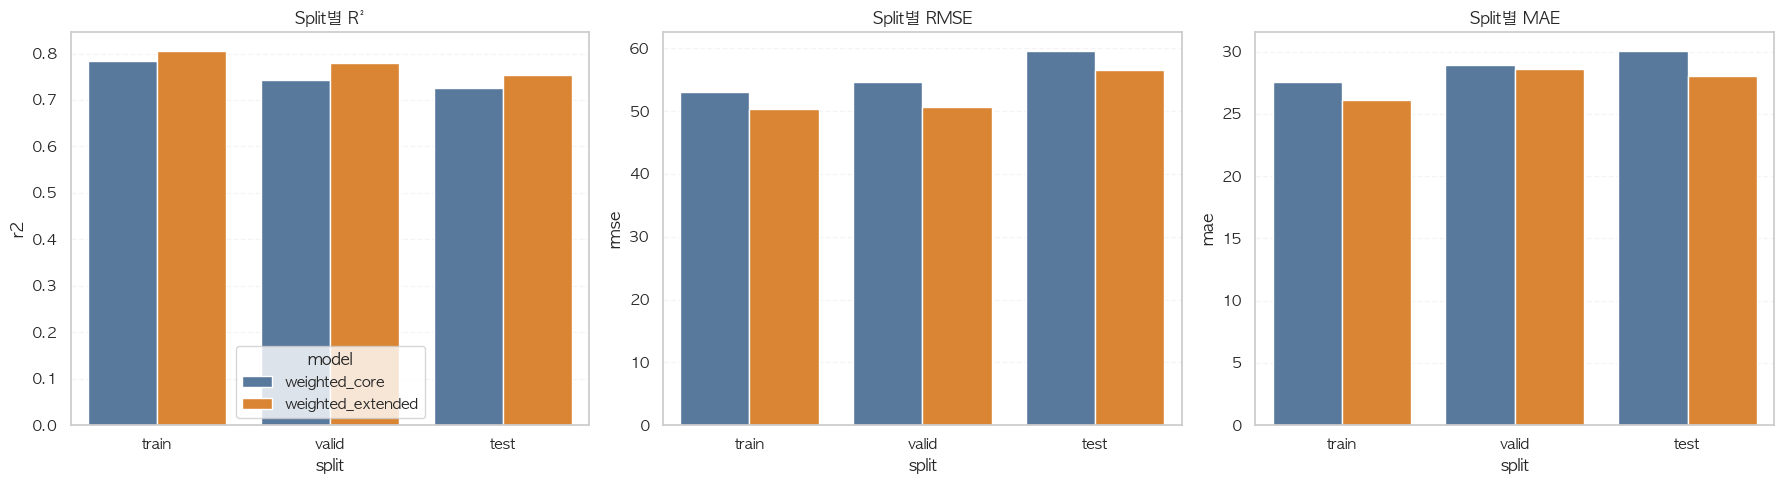

In [14]:
plot_metrics = metrics_df.copy()
plot_metrics['split'] = pd.Categorical(plot_metrics['split'], categories=['train', 'valid', 'test'], ordered=True)
plot_metrics = plot_metrics.sort_values(['split', 'model_name'])
palette = ['#4C78A8', '#F58518']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=plot_metrics, x='split', y='r2', hue='model_name', ax=axes[0], palette=palette)
axes[0].set_title('Split별 R²')
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=plot_metrics, x='split', y='rmse', hue='model_name', ax=axes[1], palette=palette)
axes[1].set_title('Split별 RMSE')
axes[1].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=plot_metrics, x='split', y='mae', hue='model_name', ax=axes[2], palette=palette)
axes[2].set_title('Split별 MAE')
axes[2].grid(axis='y', alpha=0.2, linestyle='--')

for ax in axes[1:]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()
axes[0].legend(title='model', frameon=True)

plt.tight_layout()
plt.show()



## 7-1. 보조 비교: 날씨만 추가한 모델

현재 노트북의 정식 모델은 `weighted_core`, `weighted_extended` 두 가지입니다.

다만 별도 비교 실험으로, `weighted_core`에 **날씨 feature만 추가하고 교통/자전거/행사 변수는 제외한 모델**도 따로 확인했습니다. 여기서는 이 모델을 설명 편의상 `weather_only_extended`라고 부릅니다.

구성 방식:

- 기본 패턴 feature: `base_value`, `month_weight`, `hour_weight`, `pattern_prior`, `corrected_pattern_prior`, `day_type_offday`
- 캘린더/주기 feature: `hour_sin`, `hour_cos`, `month_sin`, `month_cos`, `is_holiday`, `is_long_weekend`
- 날씨 feature만 추가: `temperature_2m`, `relative_humidity_2m`, `dew_point_2m`, `apparent_temperature`, `precipitation`, `rain`, `snowfall`, `snow_depth`, `weather_code`, `pressure_msl`, `surface_pressure`, `cloud_cover*`, `wind_*`, `shortwave_radiation`, `direct_radiation`, `diffuse_radiation`, `sunshine_duration`, `weather_feature_available`

즉 `weighted_extended`에서 교통/행사 관련 feature를 빼고, **미래 예보 API로 확보 가능한 날씨 변수만 남긴 확장형**이라고 보면 됩니다.



,model_name,split,rmse,mae,r2
1,weather_only_extended,test,53.621104,27.080325,0.777747
2,weighted_extended,test,55.528756,27.662480,0.761652
0,weighted_core,test,58.956105,29.545367,0.731321


/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_26026/687703481.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_only_comparison, x='model_name', y='r2', ax=axes[0], palette=['#4C78A8', '#54A24B', '#F58518'])
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_26026/687703481.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_only_comparison, x='model_name', y='rmse', ax=axes[1], palette=['#4C78A8', '#54A24B', '#F58518'])
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_26026/687703481.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` an

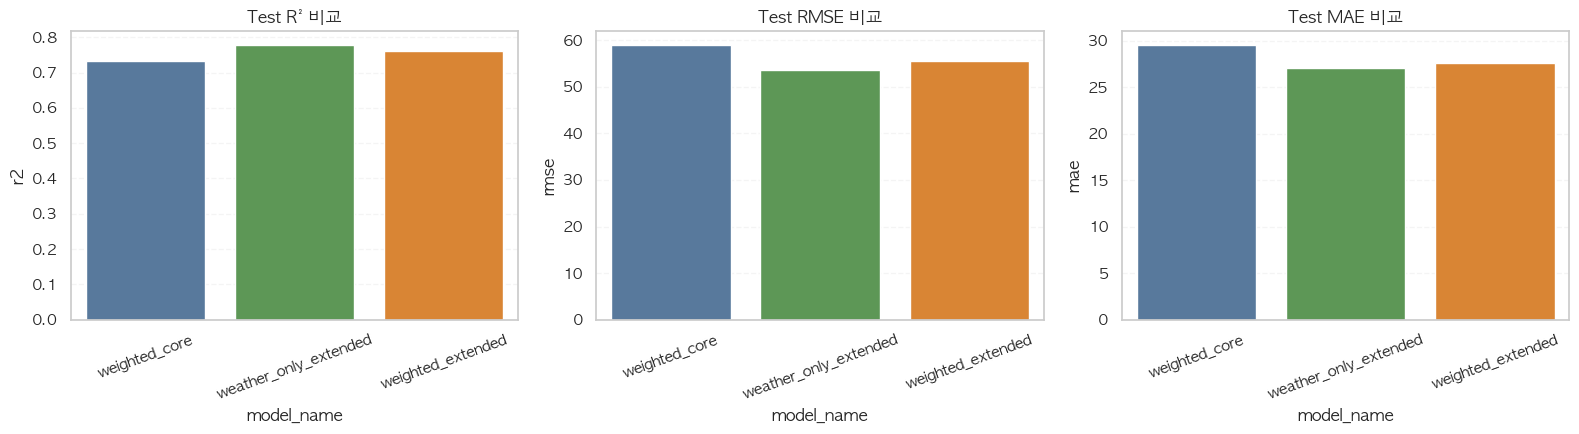

해석: 날씨만 추가한 모델은 weighted_core보다 분명히 개선됐고, 전체 weighted_extended보다도 더 좋게 나왔습니다.
즉 현재 데이터에서는 교통/행사 전체를 넣는 것보다, 날씨만 선별적으로 추가하는 쪽이 더 효율적일 가능성이 있습니다.


In [15]:
weather_only_comparison = pd.DataFrame([
    {'model_name': 'weighted_core', 'split': 'test', 'rmse': 58.956105, 'mae': 29.545367, 'r2': 0.731321},
    {'model_name': 'weather_only_extended', 'split': 'test', 'rmse': 53.621104, 'mae': 27.080325, 'r2': 0.777747},
    {'model_name': 'weighted_extended', 'split': 'test', 'rmse': 55.528756, 'mae': 27.662480, 'r2': 0.761652},
])

display(weather_only_comparison.sort_values('r2', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(data=weather_only_comparison, x='model_name', y='r2', ax=axes[0], palette=['#4C78A8', '#54A24B', '#F58518'])
axes[0].set_title('Test R² 비교')
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=weather_only_comparison, x='model_name', y='rmse', ax=axes[1], palette=['#4C78A8', '#54A24B', '#F58518'])
axes[1].set_title('Test RMSE 비교')
axes[1].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=weather_only_comparison, x='model_name', y='mae', ax=axes[2], palette=['#4C78A8', '#54A24B', '#F58518'])
axes[2].set_title('Test MAE 비교')
axes[2].grid(axis='y', alpha=0.2, linestyle='--')

for ax in axes:
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('해석: 날씨만 추가한 모델은 weighted_core보다 분명히 개선됐고, 전체 weighted_extended보다도 더 좋게 나왔습니다.')
print('즉 현재 데이터에서는 교통/행사 전체를 넣는 것보다, 날씨만 선별적으로 추가하는 쪽이 더 효율적일 가능성이 있습니다.')



,model_name,feature,alpha,coefficient,importance_abs,importance_ratio
0,weighted_extended,snow_depth,1000.0,-71.614204,71.614204,0.278573
1,weighted_extended,hour_weight,1000.0,59.460937,59.460937,0.231298
2,weighted_extended,month_weight,1000.0,36.975135,36.975135,0.143830
3,weighted_extended,snowfall,1000.0,28.856009,28.856009,0.112248
4,weighted_extended,is_holiday,1000.0,-18.869930,18.869930,0.073402
5,weighted_extended,month_cos,1000.0,12.905584,12.905584,0.050202
6,weighted_extended,hour_cos,1000.0,7.880389,7.880389,0.030654
7,weighted_extended,hour_sin,1000.0,6.333974,6.333974,0.024639
8,weighted_extended,subway_feature_available,1000.0,-3.465561,3.465561,0.013481
9,weighted_extended,month_sin,1000.0,3.192294,3.192294,0.012418


,hour,core_abs_error,extended_abs_error
15,15,63.089204,58.306367
16,16,63.118484,58.031439
17,17,62.134623,57.297714
14,14,61.864671,57.196226
18,18,58.664667,54.114247
13,13,58.877126,54.023255
12,12,53.603874,49.689795
19,19,51.386938,45.246730
11,11,45.783179,43.669794
20,20,39.853727,37.938934


,month,core_abs_error,extended_abs_error
8,9,49.655793,51.002380
3,4,42.681606,38.256020
5,6,38.528365,35.391957
9,10,35.505451,33.652235
4,5,35.915225,32.772217
7,8,29.339878,26.978130
6,7,28.603327,25.559440
2,3,25.035276,21.408204
0,1,20.596722,18.991044
11,12,20.108165,18.926074


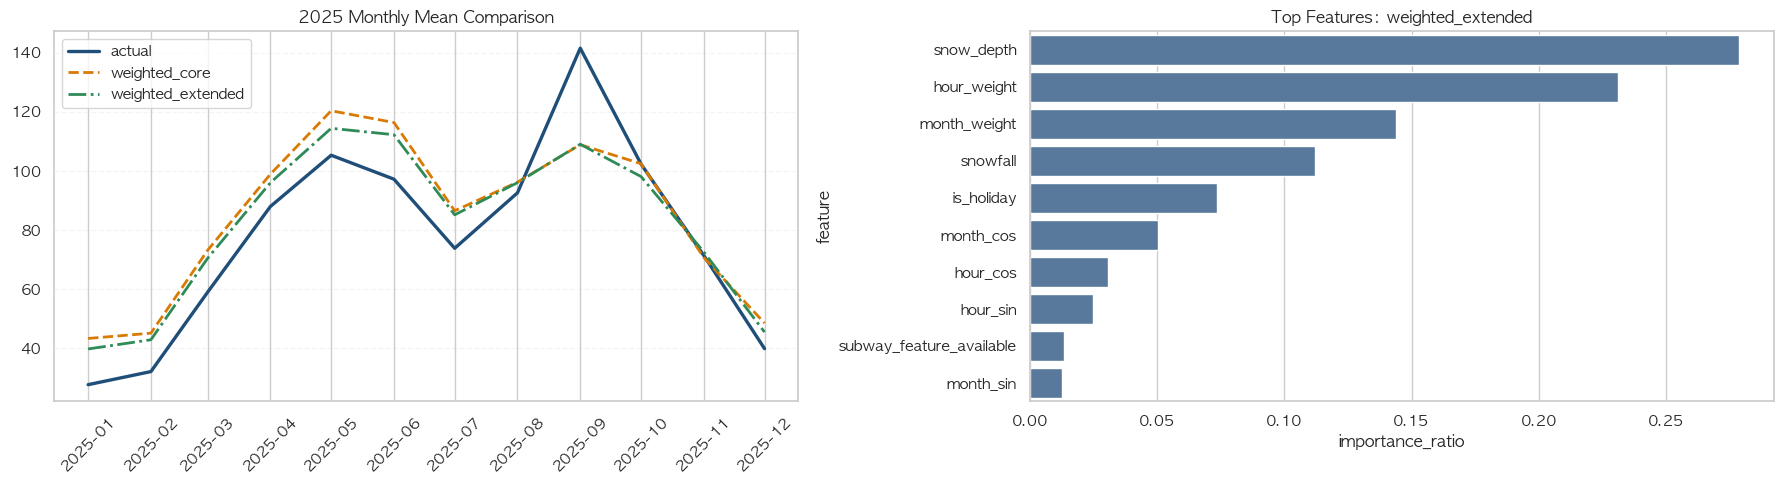

In [16]:
top_importance = (
    importance_df[importance_df['model_name'] == recommended_model]
    .sort_values('importance_ratio', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

test_df = processed_splits['test'].copy()
compare_target = f'{recommended_model}_prediction'
test_df['core_abs_error'] = np.abs(test_df[TARGET] - test_df['weighted_core_prediction'])
test_df['extended_abs_error'] = np.abs(test_df[TARGET] - test_df['weighted_extended_prediction'])

error_by_hour = (
    test_df.groupby('hour', as_index=False)[['core_abs_error', 'extended_abs_error']]
    .mean()
    .sort_values('extended_abs_error', ascending=False)
)
error_by_month = (
    test_df.groupby('month', as_index=False)[['core_abs_error', 'extended_abs_error']]
    .mean()
    .sort_values('extended_abs_error', ascending=False)
)

display(top_importance)
display(error_by_hour.head(10))
display(error_by_month.head(10))

monthly_compare = (
    test_df.assign(month_start=test_df['datetime'].dt.to_period('M').dt.to_timestamp())
    .groupby('month_start', as_index=False)[[TARGET, 'weighted_core_prediction', 'weighted_extended_prediction']]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(monthly_compare['month_start'], monthly_compare[TARGET], label='actual', linewidth=2.4, color='#1f4e79')
axes[0].plot(monthly_compare['month_start'], monthly_compare['weighted_core_prediction'], label='weighted_core', linestyle='--', linewidth=2.0, color='#d97a04')
axes[0].plot(monthly_compare['month_start'], monthly_compare['weighted_extended_prediction'], label='weighted_extended', linestyle='-.', linewidth=2.0, color='#2e8b57')
axes[0].set_title('2025 Monthly Mean Comparison')
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(frameon=True)
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=top_importance, x='importance_ratio', y='feature', ax=axes[1], color='#4C78A8')
axes[1].set_title(f'Top Features: {recommended_model}')
axes[1].set_xlabel('importance_ratio')
axes[1].set_ylabel('feature')

plt.tight_layout()
plt.show()



## 8. 중요 Feature 간 상관계수

추천 모델의 상위 중요 feature들 사이 상관계수를 `train` 데이터 기준으로 확인합니다.

- 기준: `importance_ratio` 상위 12개 feature
- 데이터 구간: `train(2022~2023)`
- 목적: 다중공선성 가능성, 계절성/휴일 변수 간 중복 설명 여부 파악



,selected_features
0,snow_depth
1,hour_weight
2,month_weight
3,snowfall
4,is_holiday
5,month_cos
6,hour_cos
7,hour_sin
8,subway_feature_available
9,month_sin


,feature_a,feature_b,corr,abs_corr
0,month_weight,month_cos,-0.787764,0.787764
1,hour_weight,hour_cos,-0.471831,0.471831
2,snow_depth,month_weight,-0.464677,0.464677
3,snow_depth,month_cos,0.396765,0.396765
4,month_weight,month_sin,-0.344894,0.344894
5,is_holiday,day_type_offday,0.333212,0.333212
6,hour_cos,subway_feature_available,-0.328727,0.328727
7,hour_weight,hour_sin,-0.279608,0.279608
8,hour_sin,subway_feature_available,-0.246720,0.246720
9,snow_depth,month_sin,0.147219,0.147219


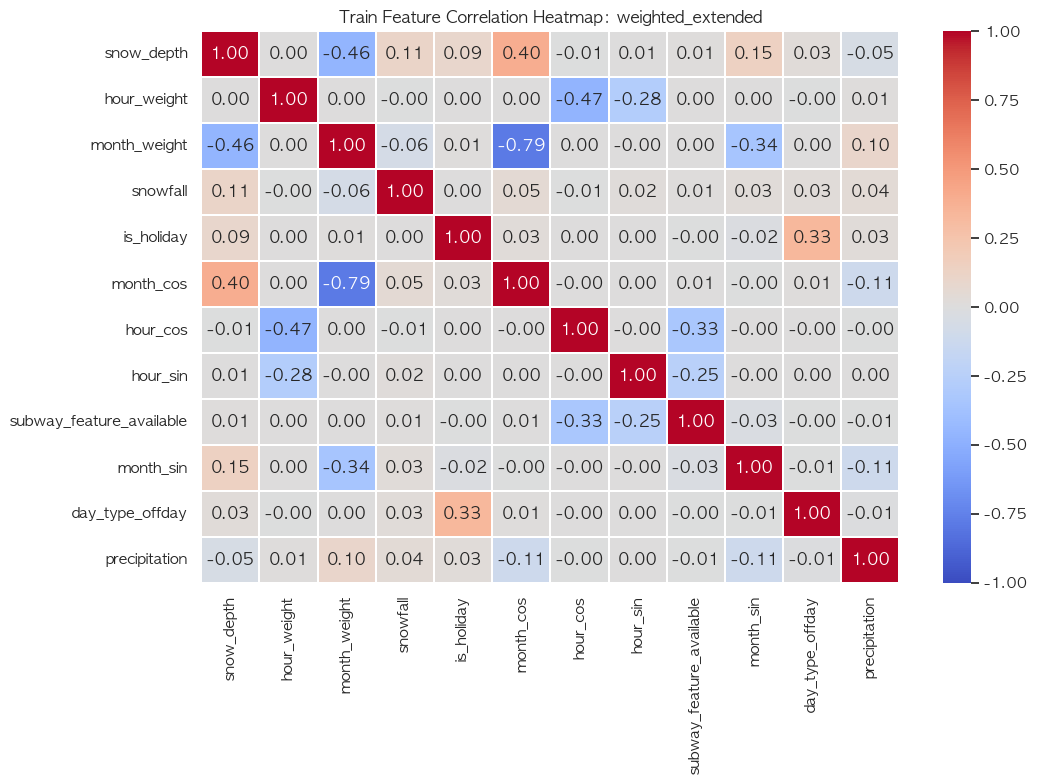

In [17]:
corr_features = (
    importance_df[importance_df['model_name'] == recommended_model]
    .sort_values('importance_ratio', ascending=False)
    .head(12)['feature']
    .tolist()
)

corr_source = processed_splits['train'][corr_features].copy()
feature_corr = corr_source.corr()

corr_pairs = []
for i, feature_a in enumerate(corr_features):
    for feature_b in corr_features[i + 1:]:
        corr_value = float(feature_corr.loc[feature_a, feature_b])
        corr_pairs.append({
            'feature_a': feature_a,
            'feature_b': feature_b,
            'corr': corr_value,
            'abs_corr': abs(corr_value),
        })
correlation_pairs_df = pd.DataFrame(corr_pairs).sort_values('abs_corr', ascending=False).reset_index(drop=True)

feature_corr.to_csv(OUTPUT_DIR / 'nanji_feature_correlation_matrix.csv', encoding='utf-8-sig')
correlation_pairs_df.to_csv(OUTPUT_DIR / 'nanji_feature_correlation_pairs.csv', index=False, encoding='utf-8-sig')

display(pd.DataFrame({'selected_features': corr_features}))
display(correlation_pairs_df.head(15))

plt.figure(figsize=(11, 8))
sns.heatmap(feature_corr, cmap='coolwarm', vmin=-1, vmax=1, center=0, annot=True, fmt='.2f', linewidths=0.2, linecolor='white')
plt.title(f'Train Feature Correlation Heatmap: {recommended_model}')
plt.tight_layout()
plt.show()



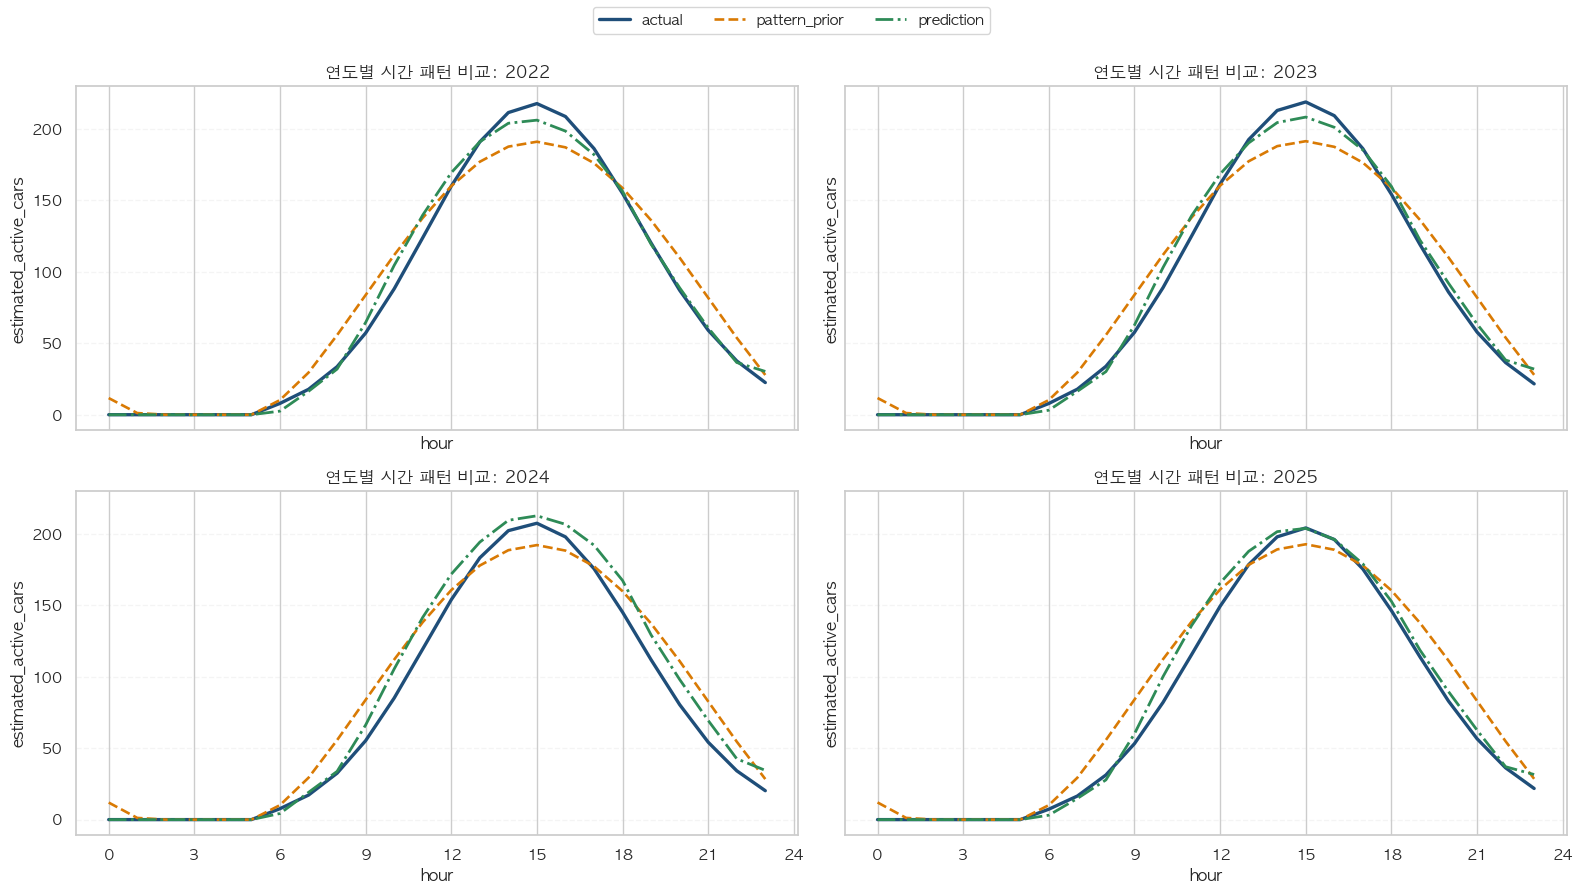

In [18]:
compare_df = pd.concat([
    processed_splits['train'],
    processed_splits['valid'],
    processed_splits['test'],
], ignore_index=True)

yearly_hour = (
    compare_df.groupby(['year', 'hour'], as_index=False)[[TARGET, compare_target, 'pattern_prior']]
    .mean()
)

years = sorted(yearly_hour['year'].unique())
ncols = 2
nrows = int(np.ceil(len(years) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()
for ax, year in zip(axes, years):
    sub = yearly_hour[yearly_hour['year'] == year]
    ax.plot(sub['hour'], sub[TARGET], label='actual', linewidth=2.4, color='#1f4e79')
    ax.plot(sub['hour'], sub['pattern_prior'], label='pattern_prior', linestyle='--', linewidth=1.9, color='#d97a04')
    ax.plot(sub['hour'], sub[compare_target], label='prediction', linestyle='-.', linewidth=2.0, color='#2e8b57')
    ax.set_title(f'연도별 시간 패턴 비교: {year}')
    ax.set_xlabel('hour')
    ax.set_ylabel(TARGET)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

for ax in axes[len(years):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



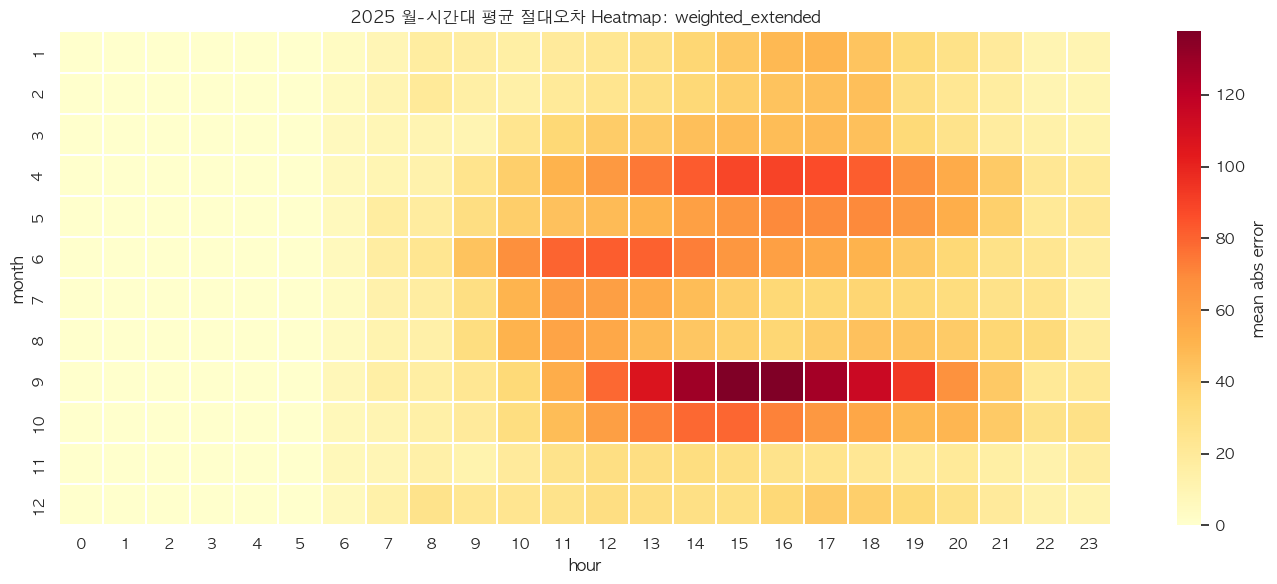

In [19]:
heatmap_df = (
    test_df.assign(abs_error=np.abs(test_df[TARGET] - test_df[compare_target]))
    .groupby(['month', 'hour'], as_index=False)['abs_error']
    .mean()
)
pivot = heatmap_df.pivot(index='month', columns='hour', values='abs_error').sort_index()

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.2, linecolor='white', cbar_kws={'label': 'mean abs error'})
plt.title(f'2025 월-시간대 평균 절대오차 Heatmap: {recommended_model}')
plt.xlabel('hour')
plt.ylabel('month')
plt.tight_layout()
plt.show()



## 8. 해석 요약

- 현재 시간별 CSV는 **하루 이용량을 단순히 24로 나눈 데이터가 아님**
- `0~5시` 행은 존재하지만 `estimated_entries`, `estimated_active_cars` 값은 모두 `0`
- 즉, 운영시간 외 시간대를 구조적으로 남겨두되 `0~5시` 수요는 0으로 간주한 데이터셋임
- 이번 분석에서는 `hour_weight`를 `6~23시`만 계산하고 `0~5시`는 가중치 산출에서 제외했으며, 최종 예측값도 `0`으로 고정함
- 현재 구조는 `year_weight` 없이 `month_weight + hour_weight` 중심으로 구성됨
- `weighted_core`는 패턴 중심 최소 모델이고, `weighted_extended`는 여기에 공휴일/교통/행사 같은 외생 변수를 더한 확장 모델임
- 연도별 차이는 완전히 없다고 보기보다는, 이번 데이터에서는 월별/시간대별 가중치와 외생 변수가 이미 대부분을 설명해 별도 `year_weight`의 실익이 작았다고 해석하는 편이 맞음
- 오프라인 성능만 보면 `weighted_extended`가 더 좋지만, 현재 시점 정보만으로 1시간 뒤~48시간 뒤를 예측하는 실사용 구조에서는 `weighted_core`를 운용 모델로 보는 것이 더 적절함
- 행사 데이터와 교통 관련 변수는 미래 예측 입력값이라기보다, 과거 수요 변동과 시기 차이를 설명하는 참고 근거로 해석하는 편이 맞음
- `lag`, `rolling` 같은 시계열 패턴 변수는 이번 설계 원칙상 사용하지 않음



## 9. 여유 주차공간 수를 구하는 방법

이번 프로젝트에서 최종적으로 활용하고 싶은 값은 `여유 주차공간 수`입니다. 다만 현재 모델이 직접 예측하는 값은 `estimated_active_cars`이므로, 이를 **추정 점유 차량 수**로 해석한 뒤 변환해야 합니다.

기본 식:

- `predicted_occupied_cars = predicted_estimated_active_cars`
- `total_capacity = 난지 주차장의 총 주차면 수`
- `available_spaces = max(total_capacity - predicted_occupied_cars, 0)`

즉, 총 주차면 수에서 해당 시점의 추정 점유 차량 수를 빼면 여유 주차공간 수가 됩니다.

실사용 예측 관점에서는 `weighted_core`를 기준 모델로 보고, 현재 시점에서 미리 알 수 있는 `hour`, `month`, `day_type`, 공휴일/주말 여부 같은 정보만으로 `1시간 뒤`, `3시간 뒤`, `24시간 뒤`, `48시간 뒤`의 점유 추정량을 계산한 뒤 여유 주차공간 수로 변환하는 방식이 적절합니다.



In [20]:
TOTAL_CAPACITY = None  # 예: 800

available_space_view = test_df[[
    'datetime', TARGET,
    'weighted_core_prediction', 'weighted_extended_prediction',
]].copy()
available_space_view = available_space_view.rename(columns={TARGET: 'actual_estimated_active_cars'})

if TOTAL_CAPACITY is not None:
    available_space_view['weighted_core_available_spaces'] = np.maximum(TOTAL_CAPACITY - available_space_view['weighted_core_prediction'], 0)
    available_space_view['weighted_extended_available_spaces'] = np.maximum(TOTAL_CAPACITY - available_space_view['weighted_extended_prediction'], 0)
    available_space_view['weighted_core_occupancy_rate'] = available_space_view['weighted_core_prediction'] / TOTAL_CAPACITY
    available_space_view['weighted_extended_occupancy_rate'] = available_space_view['weighted_extended_prediction'] / TOTAL_CAPACITY
    display(available_space_view.head())
else:
    print('TOTAL_CAPACITY 값이 없어서 절대적인 여유 주차공간 수는 아직 계산하지 않았습니다.')
    print('계산식: available_spaces = max(total_capacity - predicted_estimated_active_cars, 0)')



TOTAL_CAPACITY 값이 없어서 절대적인 여유 주차공간 수는 아직 계산하지 않았습니다.
계산식: available_spaces = max(total_capacity - predicted_estimated_active_cars, 0)


In [21]:
metrics_df.to_csv(OUTPUT_DIR / 'nanji_model_metrics.csv', index=False, encoding='utf-8-sig')
tuning_df.to_csv(OUTPUT_DIR / 'nanji_model_tuning.csv', index=False, encoding='utf-8-sig')
importance_df.to_csv(OUTPUT_DIR / 'nanji_feature_importance.csv', index=False, encoding='utf-8-sig')
weight_df.to_csv(OUTPUT_DIR / 'nanji_weight_table.csv', index=False, encoding='utf-8-sig')

test_df[[
    'datetime', TARGET, 'weighted_core_prediction', 'weighted_extended_prediction',
    'base_value', 'month_weight', 'hour_weight',
    'pattern_prior', 'corrected_pattern_prior'
]].to_csv(OUTPUT_DIR / 'nanji_test_predictions.csv', index=False, encoding='utf-8-sig')

print('saved to:', OUTPUT_DIR)
print('report path:', REPORT_PATH)



saved to: /Users/electrozone/Documents/nanji_work/hmw/Note/nanji_outputs
report path: /Users/electrozone/Documents/nanji_work/hmw/Note/nanji_weighted_ridge_modeling_report.md
